<a href="https://colab.research.google.com/github/willbueno/VWCO-Curso-IA/blob/main/2%20-%20Redes%20Neurais%20e%20Deep%20Learning/Roteiro02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Roteiro Redes Neurais e Deep Learning**
## Utilizar este Notebook para executar os comandos.
**Arquivo de referência:** *Roteiro Redes Neurais e Deep Learning.docx*

In [1]:
import torch
import keras
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, MaxPool2D, Conv2D, GlobalMaxPool2D, Flatten, Dropout
from keras import ops, layers

from tensorflow.keras.datasets import mnist

In [2]:
model = Sequential(
    [
      Input(shape=(4,)),
      Dense(4, activation='relu', name='intermediary'),
      Dense(2)
    ]
)

In [3]:
model1 = Sequential()
model1.add(Dense(4, activation='relu'))
model1.add(Dense(2))

In [4]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ intermediary (Dense)            │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
x = ops.ones((1,4))
print(x)

tf.Tensor([[1. 1. 1. 1.]], shape=(1, 4), dtype=float32)


In [7]:
model.weights

[<Variable path=sequential/intermediary/kernel, shape=(4, 4), dtype=float32, value=[[-0.74063325  0.760009    0.26936704 -0.33139157]
  [-0.23696011 -0.17108876 -0.83600265 -0.01879269]
  [ 0.7265255  -0.4821407  -0.33394235 -0.42638975]
  [ 0.5781093   0.638678   -0.19173205  0.09114885]]>,
 <Variable path=sequential/intermediary/bias, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>,
 <Variable path=sequential/dense/kernel, shape=(4, 2), dtype=float32, value=[[-0.5291655  -0.2799976 ]
  [ 0.9763608  -0.9616182 ]
  [-0.09533596 -0.0454185 ]
  [-0.20148778  0.2827437 ]]>,
 <Variable path=sequential/dense/bias, shape=(2,), dtype=float32, value=[0. 0.]>]

In [8]:
y = model(x)
print(y)

tf.Tensor([[ 0.5547765 -0.8084163]], shape=(1, 2), dtype=float32)


In [12]:
inputs = keras.Input(shape=(784,), name='digits')
x = layers.Dense(64, activation='relu', name='dense_1')(inputs)
x = layers.Dense(64, activation='relu', name='desnse_2')(x)
output = layers.Dense(10, activation='softmax', name='predictions')(x)

model = keras.Model(inputs=inputs, outputs=output)

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ digits (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ desnse_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [24]:
x_train.shape

(60000, 28, 28)

In [25]:
x_train = x_train.reshape(60000, 784).astype('float32')/255
x_test = x_test.reshape(10000, 784).astype('float32') / 255
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

In [26]:
x_train.shape

(50000, 784)

In [27]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
)

In [28]:
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=4,
    validation_data=(x_val, y_val)
)

Epoch 1/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5737 - sparse_categorical_accuracy: 0.8409 - val_loss: 0.1836 - val_sparse_categorical_accuracy: 0.9472
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1712 - sparse_categorical_accuracy: 0.9490 - val_loss: 0.1405 - val_sparse_categorical_accuracy: 0.9557
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1204 - sparse_categorical_accuracy: 0.9653 - val_loss: 0.1226 - val_sparse_categorical_accuracy: 0.9651
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0928 - sparse_categorical_accuracy: 0.9712 - val_loss: 0.1072 - val_sparse_categorical_accuracy: 0.9692


In [31]:
print(history.history)

{'loss': [0.3436291515827179, 0.16191041469573975, 0.1173587292432785, 0.09316351264715195], 'sparse_categorical_accuracy': [0.9030600190162659, 0.951200008392334, 0.9655799865722656, 0.9714000225067139], 'val_loss': [0.18360444903373718, 0.14050732553005219, 0.12256616353988647, 0.10719010978937149], 'val_sparse_categorical_accuracy': [0.9472000002861023, 0.9556999802589417, 0.9650999903678894, 0.9692000150680542]}


In [32]:
results = model.evaluate(x_test, y_test, batch_size=128)
print(results)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1105 - sparse_categorical_accuracy: 0.9664
[0.10319243371486664, 0.9684000015258789]


In [33]:
print(y_test[0])
print(y_test[1])
print(y_test[2])

7.0
2.0
1.0


In [34]:
predictions = model.predict(x_test[:3])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
[[6.4277788e-07 1.7471914e-06 3.1478419e-05 4.0261226e-04 5.4514843e-10
  8.4193907e-08 4.7535587e-12 9.9955064e-01 2.5464919e-06 1.0184132e-05]
 [2.7781591e-06 1.5715871e-03 9.9793088e-01 4.8139109e-04 1.0245331e-11
  6.4828032e-06 4.8820164e-07 2.5667942e-11 6.3926768e-06 1.7627267e-12]
 [4.8280449e-06 9.9911910e-01 2.1769365e-04 5.7252528e-05 2.5875511e-04
  5.7770962e-06 4.8366976e-05 2.3193289e-04 5.3273132e-05 2.9389273e-06]]


In [36]:
print('test_loss, test acc:', results,'| predictions shape: ', predictions.shape)

test_loss, test acc: [0.10319243371486664, 0.9684000015258789] | predictions shape:  (3, 10)


In [37]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense

In [40]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], x_train.shape[2], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))

In [41]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [42]:
x_train = x_train/255
x_test = x_test/255

In [43]:
model = Sequential()
model.add(Conv2D(32, 3, activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(2,2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [45]:
model.compile(
  loss='sparse_categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy'],
)

In [52]:
processo = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9990 - val_loss: 0.0030
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9990 - loss: 0.0029 - val_accuracy: 0.9980 - val_loss: 0.0052
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9972 - val_loss: 0.0071
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9988 - loss: 0.0027 - val_accuracy: 0.9995 - val_loss: 0.0033
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9983 - val_loss: 0.0073
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9993 - loss: 0.0020 - val_accuracy: 0.9960 - val_loss: 0.0153
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9987 - val_loss: 0.0042
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9999 -

In [53]:
import matplotlib.pyplot as plt

In [54]:
model.evaluate(x_test, y_test)
model.predict(x_test[:1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9829 - loss: 0.0975
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[5.45814606e-15, 2.43486922e-14, 1.11281318e-12, 2.22078189e-11,
        3.58185815e-17, 1.11554115e-17, 4.75073238e-25, 1.00000000e+00,
        1.95789305e-12, 3.43146044e-16]], dtype=float32)

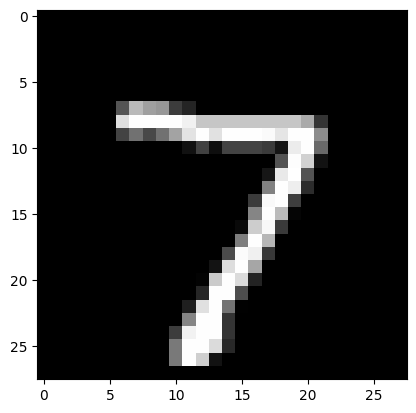

In [55]:
plt.imshow(x_test[0], cmap='gray')

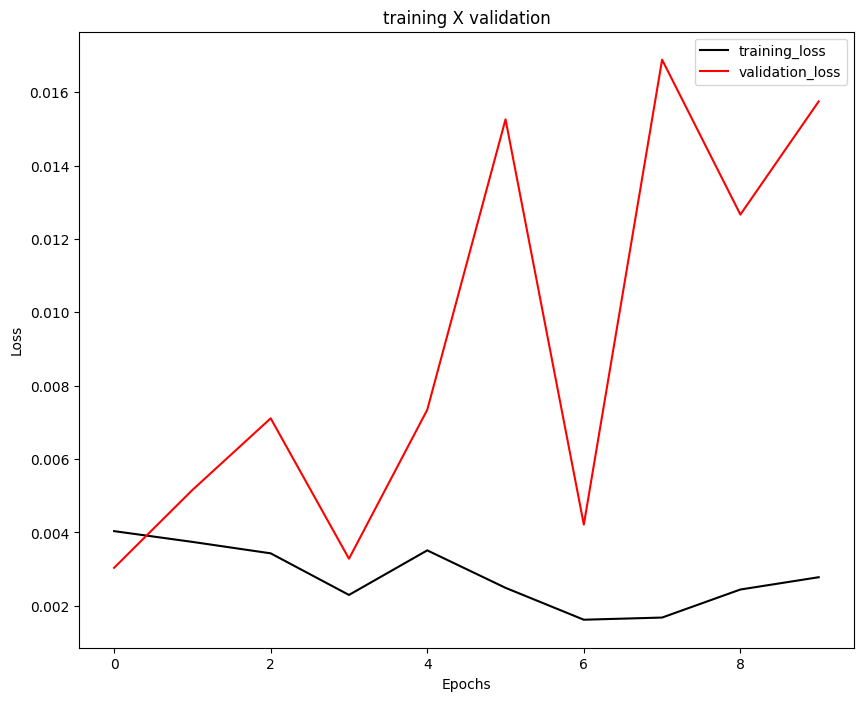

In [56]:
fig = plt.figure(figsize=(10,8))
ax = fig.gca()

ax.set(title='training X validation')
ax.plot(processo.history['loss'], color='black', label='training_loss')
ax.plot(processo.history['val_loss'], color='red', label='validation_loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

In [57]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
from tensorflow.keras.datasets import cifar10

In [58]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [59]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Text(0.5, 1.0, 'Label: [4]')

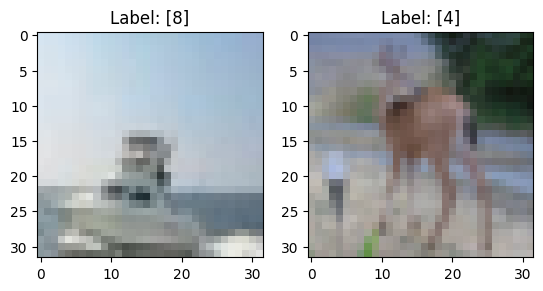

In [60]:
np.unique(y_train)
img = 100
plt.subplot(121)
plt.imshow(x_train[img])
plt.title('Label: {}'.format(y_train[img]))
plt.subplot(122)
plt.imshow(x_test[img])
plt.title('Label: {}'.format(y_test[img]))

In [61]:
x_train = x_train / 255
x_test = x_test / 255

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [62]:
model=Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(216, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

In [63]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 216)            │       497,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 519,442 (1.98 MB)

 Trainable params: 519,442 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [65]:
progresso = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.3322 - loss: 1.8235 - val_accuracy: 0.5381 - val_loss: 1.3088
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.5516 - loss: 1.2575 - val_accuracy: 0.6282 - val_loss: 1.0887
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6216 - loss: 1.0922 - val_accuracy: 0.6183 - val_loss: 1.0898
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.6444 - loss: 1.0069 - val_accuracy: 0.6682 - val_loss: 0.9667
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.6716 - loss: 0.9526 - val_accuracy: 0.6823 - val_loss: 0.9327
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.6945 - loss: 0.8888 - val_accuracy: 0.6898 - val_loss: 0.9515
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.7039 - loss: 0.8605 - val_accuracy: 0.7006 - val_loss: 0.9003
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.7106 -

In [66]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6820 - loss: 0.9597


[0.9538849592208862, 0.6820999979972839]

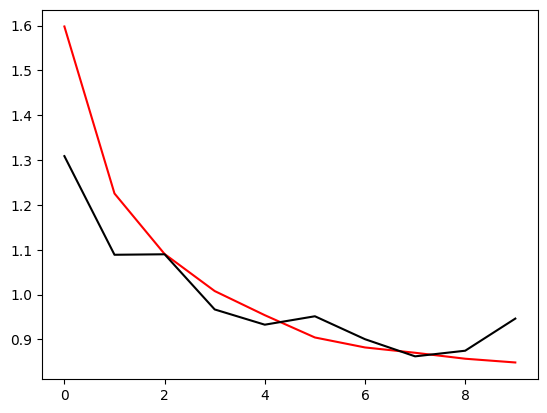

In [67]:
plt.plot(progresso.history['loss'], color='red')
plt.plot(progresso.history['val_loss'], color='black')
plt.show()

In [68]:
pred = model.predict(x_test)
print(pred[0])
print('Index:', np.argmax(pred[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
[0.00207972 0.00149491 0.02838919 0.52037257 0.03313985 0.2097854
 0.17137803 0.00435449 0.02592843 0.00307734]
Index: 3


In [69]:
y_classes = [np.argmax(element) for element in pred]
print('Predicted_values: ', y_classes[:10])
print('Actual_values: ', y_test[:10])

Predicted_values:  [np.int64(3), np.int64(1), np.int64(1), np.int64(0), np.int64(6), np.int64(6), np.int64(1), np.int64(6), np.int64(3), np.int64(1)]
Actual_values:  [3 8 8 0 6 6 1 6 3 1]
